## Dataset Overview

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn_2.csv')
print(f"Dataset shape -- {df.shape}")
print(df.dtypes)

Dataset shape -- (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


I found 7043 rows and 21 columns in this dataset. Most features are object types, which usually indicates categorical variables.

In [11]:
print(f"TotalCharges nulls before coercion -- {df['TotalCharges'].isnull().sum()}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges nulls after coercion -- {df['TotalCharges'].isnull().sum()}")

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"TotalCharges nulls after fill -- {df['TotalCharges'].isnull().sum()}")

TotalCharges nulls before coercion -- 0
TotalCharges nulls after coercion -- 11
TotalCharges nulls after fill -- 0


11 rows contain blank strings instead of nulls, which forced the TotalCharges column to load as an object dtype. All 11 of these rows have a tenure of 0, meaning they are brand-new customers who have not yet incurred any charges. I coerced these blanks to numeric nulls and filled them with 0 to keep these valid **customers** in the dataset. I verified no other columns contain missing values.

## Target Variable Distribution

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rates:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


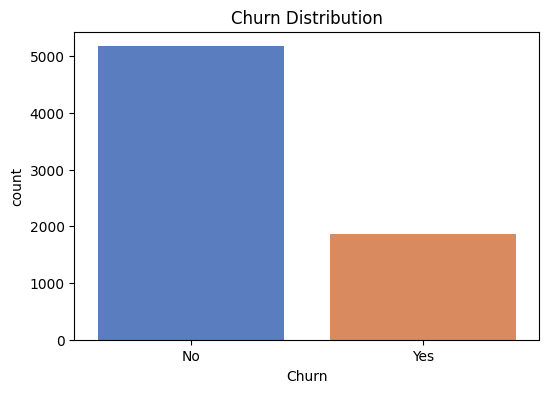

In [12]:
churn_counts = df['Churn'].value_counts()
churn_rates = df['Churn'].value_counts(normalize=True) * 100

print(f"Churn counts:\n{churn_counts}")
print(f"Churn rates:\n{churn_rates}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='muted')
plt.title('Churn Distribution')
plt.show()

26.5% of the customers in this dataset have churned. This indicates a moderate class **imbalance** I need to account for. Stratification preserves the split ratio, and imbalance is handled by scale_pos_weight in training.

## Churn vs. Numerical Features

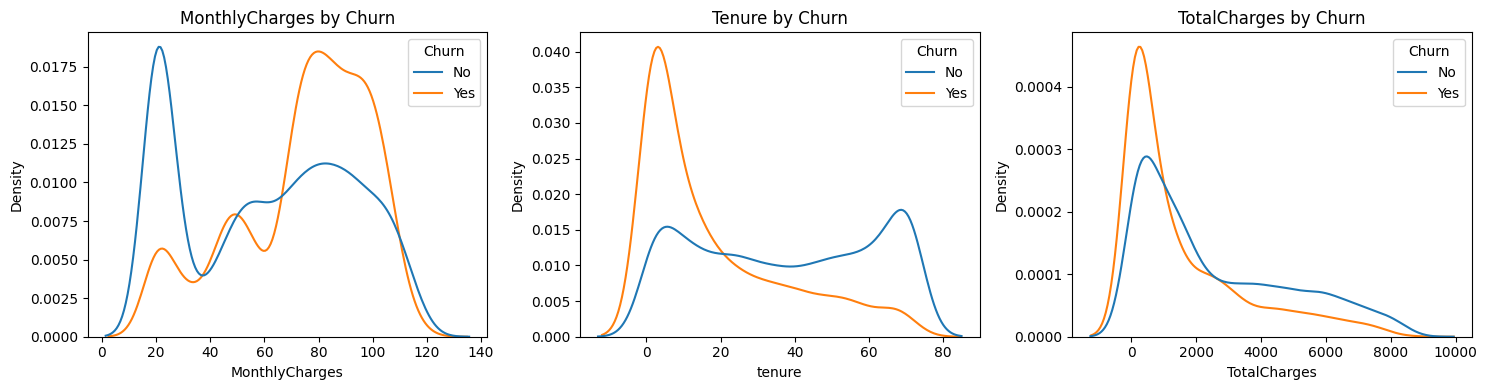

Median tenure for churners -- 10.0 months
Median tenure for non-churners -- 38.0 months
Average MonthlyCharges for churners -- $74.4
Average MonthlyCharges for non-churners -- $61.3


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[0], common_norm=False)
axes[0].set_title('MonthlyCharges by Churn')

sns.kdeplot(data=df, x='tenure', hue='Churn', ax=axes[1], common_norm=False)
axes[1].set_title('Tenure by Churn')

sns.kdeplot(data=df, x='TotalCharges', hue='Churn', ax=axes[2], common_norm=False)
axes[2].set_title('TotalCharges by Churn')
plt.tight_layout()
plt.show()

print(f"Median tenure for churners -- {df[df['Churn'] == 'Yes']['tenure'].median()} months")
print(f"Median tenure for non-churners -- {df[df['Churn'] == 'No']['tenure'].median()} months")
print(f"Average MonthlyCharges for churners -- ${df[df['Churn'] == 'Yes']['MonthlyCharges'].mean():.1f}")
print(f"Average MonthlyCharges for non-churners -- ${df[df['Churn'] == 'No']['MonthlyCharges'].mean():.1f}")

Churners have a median tenure of 10 months versus 38 months for non-churners. The first year represents the highest-risk **window** for customer attrition. I noticed churners pay higher monthly charges on average at $74.40 compared to $61.30 for retained customers, so they are paying more but still choosing to leave.

## Churn vs. Categorical Features

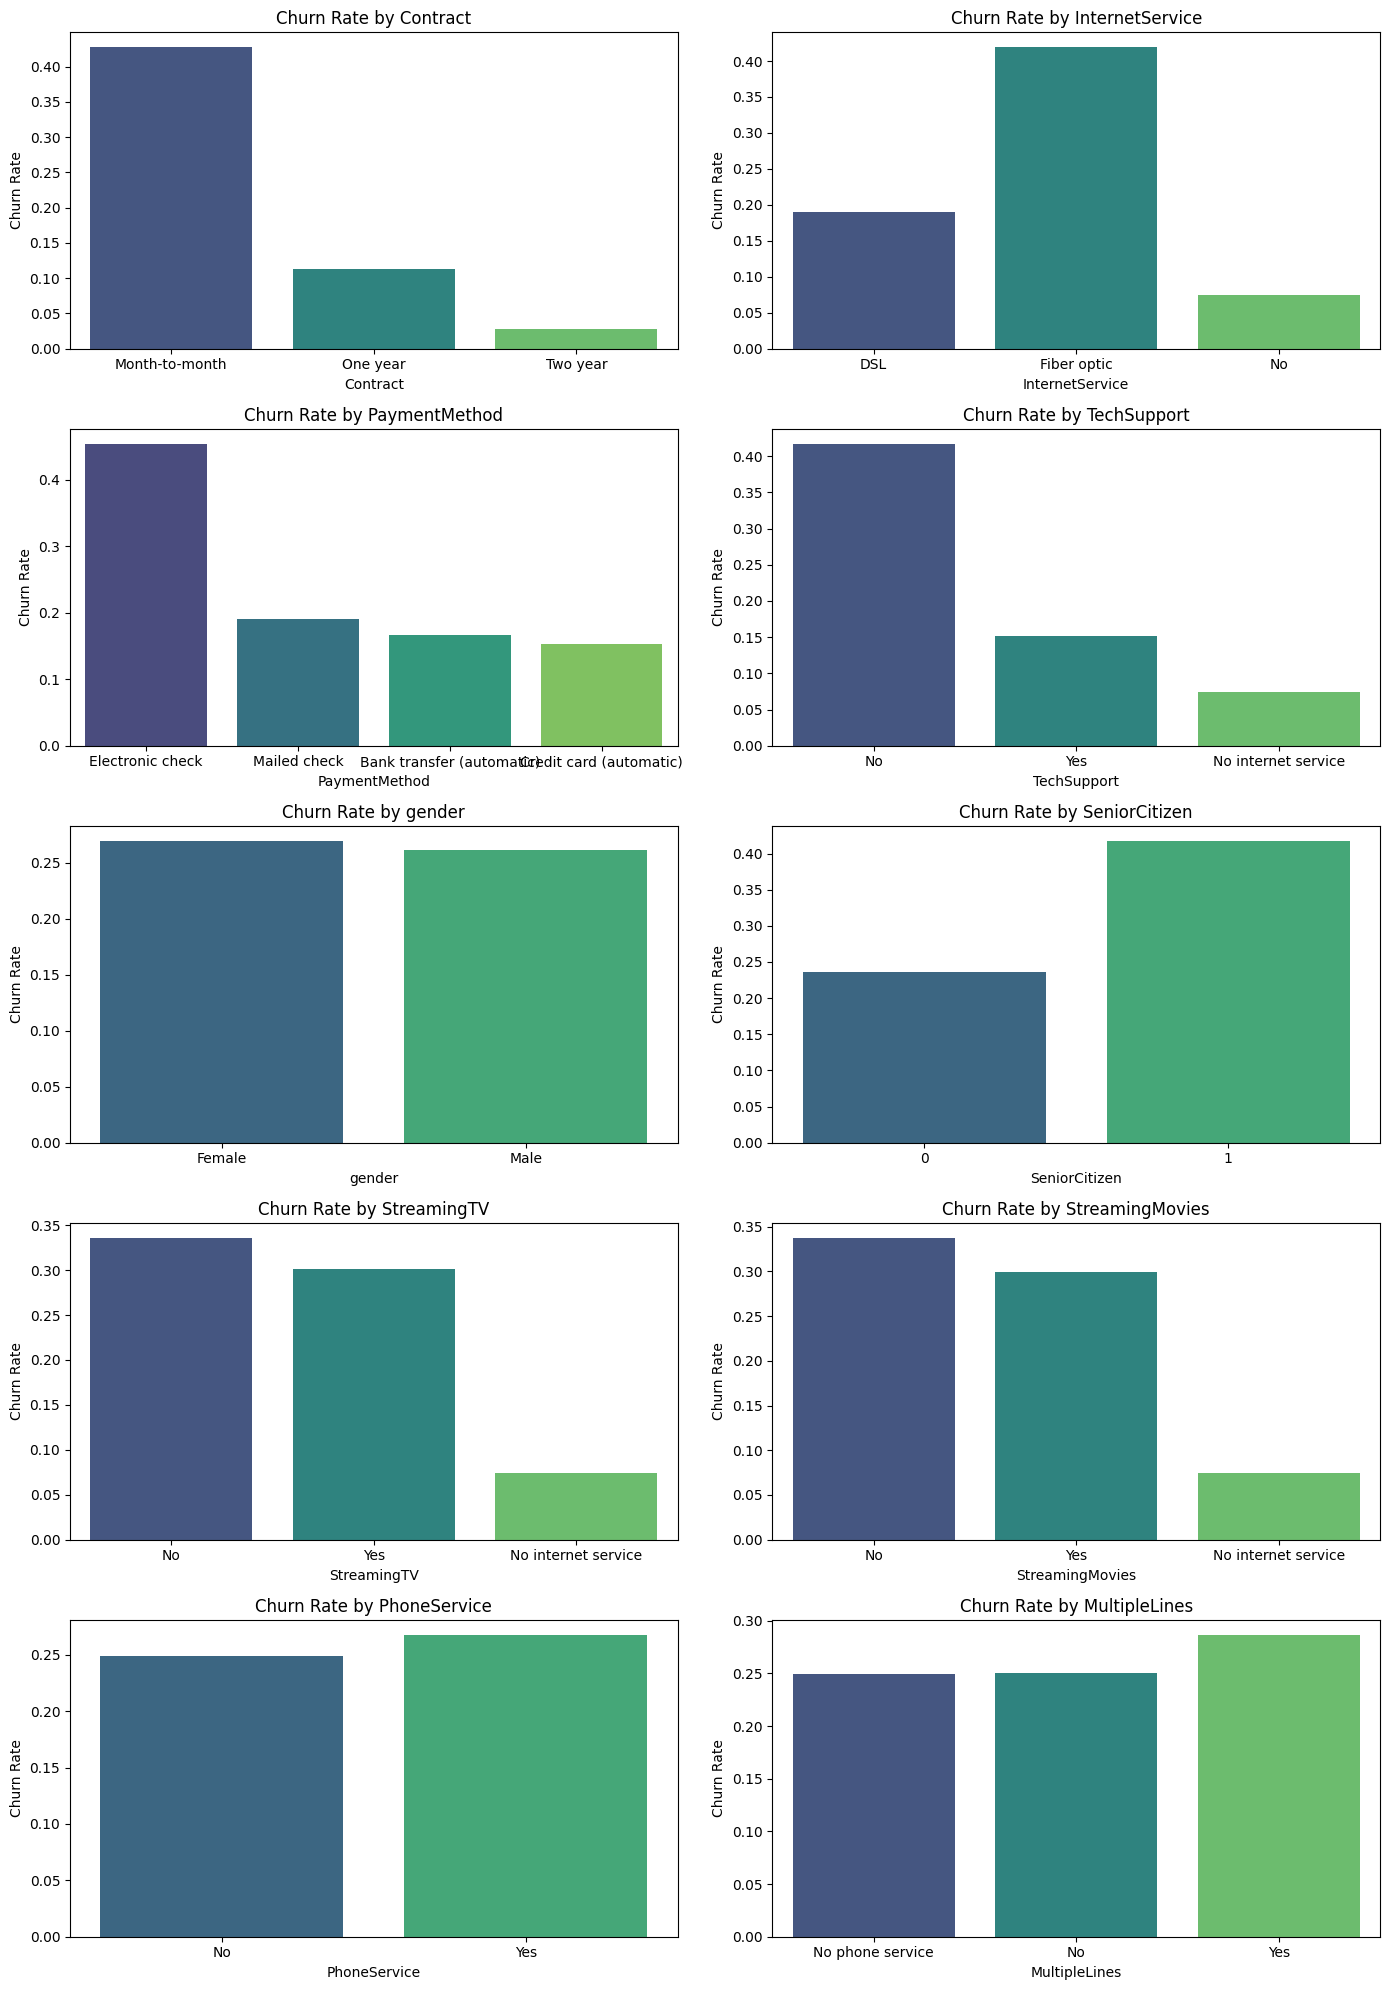

In [14]:
categorical_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'gender', 'SeniorCitizen', 'StreamingTV', 'StreamingMovies', 'PhoneService', 'MultipleLines']

df_plot = df.copy()
df_plot['Churn_num'] = df_plot['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.barplot(data=df_plot, x=feature, y='Churn_num', ax=axes[i], errorbar=None, palette='viridis')
    axes[i].set_title(f'Churn Rate by {feature}')
    axes[i].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

Month-to-month contract customers churn at a rate of 42.7% versus 11.3% for one-year and only 2.8% for two-year contracts, making contract type the single strongest **predictor** of churn. Fiber optic customers churn at 41.9%, nearly double the rate for DSL at 19.0% and over five times the 7.4% rate for customers with no internet. They are paying more but seem to be the least satisfied segment, suggesting a pricing or value mismatch.\n\nElectronic check payment users have a 45.3% churn rate, the highest of all payment methods and nearly triple the rates for credit card at 15.2% and bank transfer at 16.7%. Customers without TechSupport churn at 41.6% compared to 15.2% for those with it, showing that add-on services are strongly protective.\n\nFemale and male customers have nearly identical churn rates at 26.9% and 26.2%, so I will drop gender from the narrative going forward because it adds no signal. Seniors churn at 41.7% versus 23.6% for non-seniors, providing a meaningful demographic signal. Streaming TV and StreamingMovies show no meaningful difference in churn rate among internet users, hovering around 30% to 34%. I expected these entertainment features to matter, but they are a genuine dead-end. PhoneService and MultipleLines are also near-useless predictors with churn rates nearly identical across all categories at roughly 25% to 28%.

## Correlation Analysis

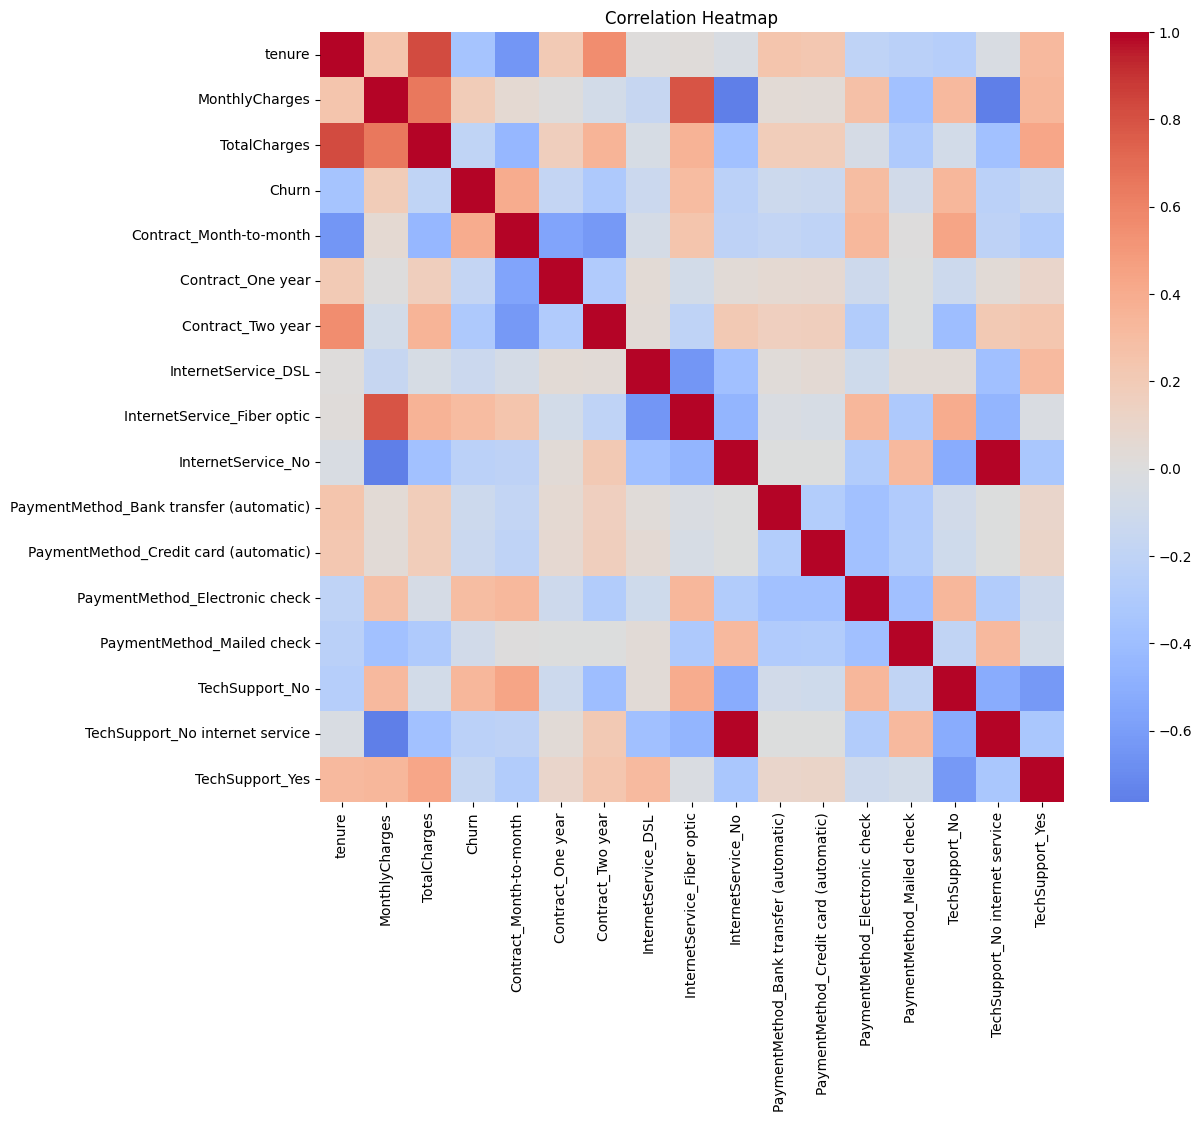

In [15]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

cols_to_encode = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
df_corr = pd.get_dummies(df_corr, columns=cols_to_encode, drop_first=False)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'] + [col for col in df_corr.columns if col.startswith(tuple(cols_to_encode))]

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr[numeric_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Month-to-month contracts and fiber optic internet show the strongest positive **correlation** with the churn label. Tenure shows a strong negative correlation with churn, reinforcing that longer-tenured customers are less likely to leave.

## Feature Engineering

In [16]:
df_model = df.copy()
df_model = df_model.drop(columns=['gender'])

bins = [-1, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df_model['tenure_group'] = pd.cut(df_model['tenure'], bins=bins, labels=labels)

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')
    
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Encoded dataset shape -- {df_encoded.shape}")
print(df_encoded[['tenure', 'tenure_group_13-24', 'tenure_group_25-48']].head())

Encoded dataset shape -- (7043, 34)
   tenure  tenure_group_13-24  tenure_group_25-48
0       1               False               False
1      34               False                True
2       2               False               False
3      45               False                True
4       2               False               False


I dropped the gender column because it provided no predictive value. I grouped tenure into discrete **bins** representing the first year, second year, two to four years, and over four years to capture the non-linear risk associated with customer age. I then one-hot encoded the remaining categorical features and converted the target to a binary format.

## Train/Test Split

In [17]:
X = df_encoded.drop(columns=['Churn', 'customerID'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape -- {X_train.shape}")
print(f"X_test shape -- {X_test.shape}")
print(f"Training churn rate -- {y_train.mean():.3f}")
print(f"Testing churn rate -- {y_test.mean():.3f}")

X_train shape -- (5634, 32)
X_test shape -- (1409, 32)
Training churn rate -- 0.265
Testing churn rate -- 0.265


The data is now split into 80% training and 20% testing sets. I stratified the split based on the target variable to ensure both sets maintain the exact 26.5% churn **rate** present in the full dataset.

In [18]:
import os

os.makedirs('../data/processed', exist_ok=True)

# Convert all column names to strings to avoid parquet issues
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

X_train.to_parquet('../data/processed/X_train.parquet')
X_test.to_parquet('../data/processed/X_test.parquet')

pd.DataFrame(y_train).to_parquet('../data/processed/y_train.parquet')
pd.DataFrame(y_test).to_parquet('../data/processed/y_test.parquet')

print("Saved processed splits to data/processed/ -- success")

Saved processed splits to data/processed/ -- success


I saved the resulting training and testing splits to the processed data directory in parquet format. This preserves the data **types** and column structures for downstream modeling.